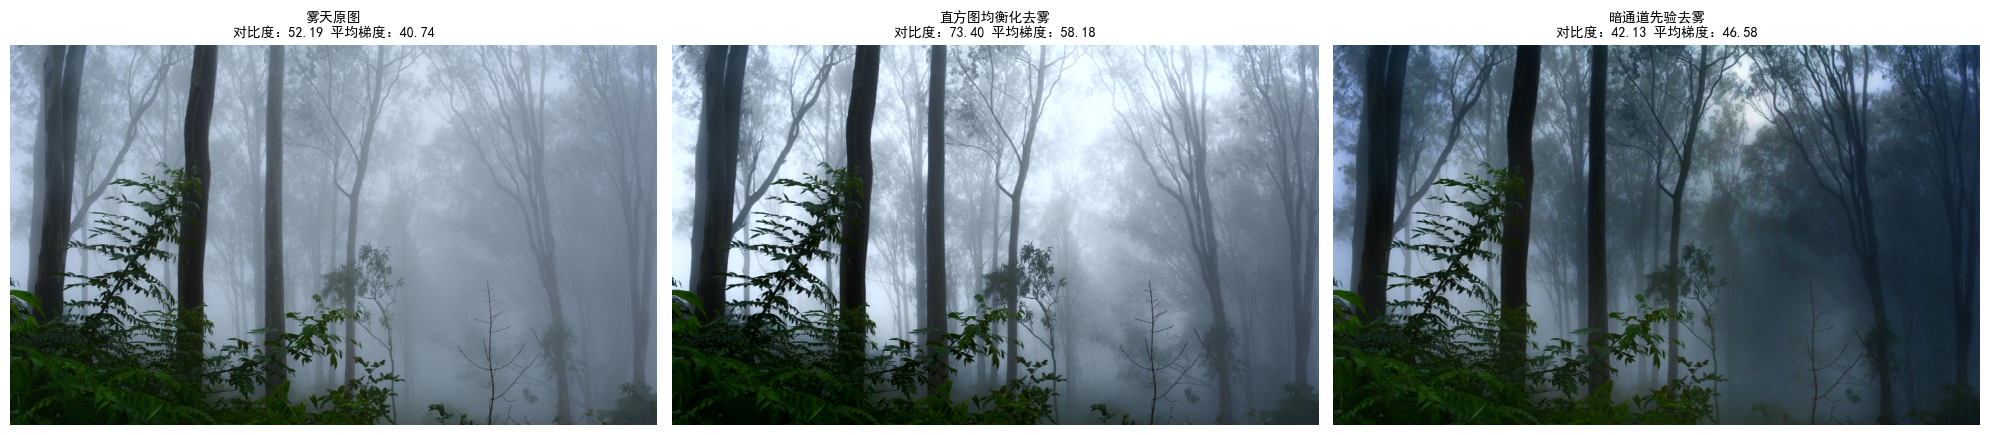

去雾效果量化对比
原图对比度：52.19 | 直方图去雾：73.40 | 暗通道去雾：42.13
原图平均梯度：40.74 | 直方图去雾：58.18 | 暗通道去雾：46.58


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def histogram_dehazing(img_rgb):
    ycrcb_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
    y_channel, cr_channel, cb_channel = cv2.split(ycrcb_img)
    eq_y_channel = cv2.equalizeHist(y_channel)
    eq_ycrcb_img = cv2.merge([eq_y_channel, cr_channel, cb_channel])
    dehazed_rgb = cv2.cvtColor(eq_ycrcb_img, cv2.COLOR_YCrCb2RGB)
    return dehazed_rgb

def dark_channel(img, window_size=15):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (window_size, window_size))
    min_channel = cv2.min(cv2.min(img[:, :, 0], img[:, :, 1]), img[:, :, 2])
    dark_img = cv2.erode(min_channel, kernel)
    return dark_img

def estimate_atmospheric_light(img, dark_img):
    h, w = img.shape[:2]
    num_pixels = int(h * w * 0.001)
    dark_flat = dark_img.flatten()
    img_flat = img.reshape(-1, 3)
    idx = dark_flat.argsort()[::-1][:num_pixels]
    atmospheric_light = np.mean(img_flat[idx], axis=0)
    return atmospheric_light

def estimate_transmission(img, atmospheric_light, window_size=15, omega=0.95):
    norm_img = img / atmospheric_light
    norm_dark = dark_channel(norm_img, window_size)
    transmission = 1 - omega * norm_dark
    return transmission

def guided_filter(img, guide, radius=60, eps=1e-3):
    img_32f = img.astype(np.float32)
    guide_8u = (guide * 255).astype(np.uint8) if guide.max() <= 1 else guide.astype(np.uint8)
    return cv2.ximgproc.guidedFilter(guide=guide_8u, src=img_32f, radius=radius, eps=eps)

def recover_scene(img, atmospheric_light, transmission, t0=0.1):
    transmission = np.maximum(transmission, t0)
    transmission = np.expand_dims(transmission, axis=2)
    recover_img = (img - atmospheric_light) / transmission + atmospheric_light
    recover_img = np.clip(recover_img, 0, 1)
    recover_img = (recover_img * 255).astype(np.uint8)
    return recover_img

def dark_channel_dehazing(img_rgb):
    img_norm = img_rgb.astype(np.float64) / 255.0
    dark_img = dark_channel(img_norm, 15)
    atmospheric_light = estimate_atmospheric_light(img_norm, dark_img)
    transmission = estimate_transmission(img_norm, atmospheric_light, 15)
    transmission_refine = guided_filter(transmission, img_rgb[:, :, 0])
    dehazed_rgb = recover_scene(img_norm, atmospheric_light, transmission_refine)
    return dehazed_rgb

def calculate_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return np.std(gray)

def calculate_avg_gradient(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad = np.sqrt(grad_x**2 + grad_y**2)
    return np.mean(grad)

# 主测试代码
img_path = "foggy_image.png"
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise ValueError("图像路径错误或文件不存在！")
original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 两种方法去雾
histeq_dehazed = histogram_dehazing(original_rgb)
dcp_dehazed = dark_channel_dehazing(original_rgb)

# 计算评价指标
ori_contrast = calculate_contrast(original_rgb)
histeq_contrast = calculate_contrast(histeq_dehazed)
dcp_contrast = calculate_contrast(dcp_dehazed)

ori_gradient = calculate_avg_gradient(original_rgb)
histeq_gradient = calculate_avg_gradient(histeq_dehazed)
dcp_gradient = calculate_avg_gradient(dcp_dehazed)

# 可视化对比
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title(f"雾天原图\n对比度：{ori_contrast:.2f} 平均梯度：{ori_gradient:.2f}", fontsize=10)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(histeq_dehazed)
plt.title(f"直方图均衡化去雾\n对比度：{histeq_contrast:.2f} 平均梯度：{histeq_gradient:.2f}", fontsize=10)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dcp_dehazed)
plt.title(f"暗通道先验去雾\n对比度：{dcp_contrast:.2f} 平均梯度：{dcp_gradient:.2f}", fontsize=10)
plt.axis("off")

plt.tight_layout()
plt.show()

# 输出量化对比
print("="*50)
print("去雾效果量化对比")
print(f"原图对比度：{ori_contrast:.2f} | 直方图去雾：{histeq_contrast:.2f} | 暗通道去雾：{dcp_contrast:.2f}")
print(f"原图平均梯度：{ori_gradient:.2f} | 直方图去雾：{histeq_gradient:.2f} | 暗通道去雾：{dcp_gradient:.2f}")
print("="*50)